## Глоссарий 



**Целевое действие** — события типа «Оставить заявку» и «Заказать звонок»
(ga_hits.event_action in ['sub_car_claim_click', 'sub_car_claim_submit_click',
'sub_open_dialog_click', 'sub_custom_question_submit_click',
'sub_call_number_click', 'sub_callback_submit_click', 'sub_submit_success',
'sub_car_request_submit_click']).

**CR (Conversion Rate)** — показатель конверсии из визита (уникальный
session_id) в любое целевое действие в рамках одного визита (в случае
наличия >1 целевого действия — считать все как одно).

**Органический трафик** — все визиты с ga_sessions.utm_medium in ('organic',
'referral', '(none)').

**Платный трафик** — весь неорганический трафик.

**Информация про марку и модель авто** — содержится в ga_hits.hit_page_path.

**Реклама в социальных сетях** — все визиты с ga_sessions.utm_source in
('QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', 'ISrKoXQCxqqYvAZICvjs',
IZEXUFLARCUMynmHNBGo', 'PlbkrSYoHuZBWfYjYnfw',
'gVRrcxiDQubJiljoTbGm').

## Данные

#### **ga_sessions** *(одна строка = один визит на сайт)*
Описание атрибутов:
- session_id — ID визита;
- client_id — ID посетителя;
- visit_date — дата визита;
- visit_time — время визита;
- visit_number — порядковый номер визита клиента;
- utm_source — канал привлечения;
- utm_medium — тип привлечения;
- utm_campaign — рекламная кампания;
- utm_keyword — ключевое слово;
- device_category — тип устройства;
- device_os — ОС устройства;
- device_brand — марка устройства;
- device_model — модель устройства;
- device_screen_resolution — разрешение экрана;
- device_brand — марка устройства;
- device_model — модель устройства;
- device_screen_resolution — разрешение экрана;
- device_browser — браузер;
- geo_country — страна;
- geo_city — город.


#### **ga_hits** *(одна строка = одно событие в рамках одного визита на сайт)*
Описание атрибутов:
- session_id — ID визита;
- hit_date — дата события;
- hit_time — время события;
- hit_number — порядковый номер события в рамках сессии;
- hit_type — тип события;
- hit_referer — источник события;
- hit_page_path — страница события;
- event_category — тип действия;
- event_action — действие;
- event_label — тег действия;
- event_value — значение результата действия.

## Импорт библиотек

In [1]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import json
import os as os
import missingno as msno
from catboost import CatBoostClassifier
from catboost import Pool
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split



### Вспомогательные функции

In [2]:
# Анализ пропущенных значений

def analyze_missing_values(df, df_name="DataFrame"):
    
    print(f"АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ: {df_name}")

    # Расчет пропусков
    missing_count = df.isna().sum()
    missing_percentage = (missing_count / len(df)) * 100
    
    # Создаем DataFrame с результатами
    missing_df = pd.DataFrame({
        'column': missing_count.index,
        'missing_count': missing_count.values,
        'missing_percentage': missing_percentage.values
    })
    
    # Фильтруем только колонки с пропусками
    missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percentage', ascending=False)
    
    if len(missing_df) == 0:
        print("Нет пропущенных значений!")
    else:
        print(f"\n Найдено {len(missing_df)} колонок с пропусками:\n")
        for _, row in missing_df.iterrows():
            print(f"  • {row['column']:20} | {row['missing_count']:10,} пропусков | {row['missing_percentage']:5.2f}%")
    
    
    
    return missing_df

In [3]:
# Обработка дубликатов 

def handle_duplicates(df):
   
    print("ОБРАБОТКА ДУБЛИКАТОВ")
  
    # Поиск дубликатов
    duplicates_all = df.duplicated().sum()
    
    # Вывод информации
    if duplicates_all > 0:
        print(f" Кол-во дубликатов: {duplicates_all:,} ({duplicates_all/len(df)*100:.2f}%)")
            
    else:
        print("Дубликатов не найдено!")
    
    
    return duplicates_all

## Загрузка данных

In [4]:
from config import Config

df_sessions = pd.read_csv(Config.PATHS['sessions'])

chunk_size = 50000
chunks = []

for chunk in pd.read_csv(Config.PATHS['hits'], chunksize=chunk_size):
    # Обрабатываем каждый чанк
    print(f"Обработан чанк размером {len(chunk)} строк")
    chunks.append(chunk)

# Объединяем все чанки в один DataFrame
df_hits = pd.concat(chunks, ignore_index=True)

print(df_sessions.shape)
print(df_hits.shape)

C:\Users\mezoh\AppData\Local\Temp\ipykernel_18904\1577367623.py:3: DtypeWarning: Columns (0: client_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sessions = pd.read_csv(Config.PATHS['sessions'])


Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 50000 строк
Обработан чанк размером 5000

In [5]:
# Просмотр первых строк и размерности df_hits
print('Размерность Hits:', df_hits.shape)
df_hits.head(5)


Размерность Hits: (15726470, 11)


,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [6]:
# Статистическая сводка
df_hits.info()

<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      str    
 1   hit_date        str    
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        str    
 5   hit_referer     str    
 6   hit_page_path   str    
 7   event_category  str    
 8   event_action    str    
 9   event_label     str    
 10  event_value     float64
dtypes: float64(2), int64(1), str(8)
memory usage: 1.3 GB


In [7]:
# Просмотр первых строк и размерности df_sessions
print('Размерность Sessions:', df_sessions.shape)
df_sessions.head(5)

Размерность Sessions: (1860042, 18)


,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [8]:
# Статистичкая сводка 
df_sessions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                str   
 1   client_id                 object
 2   visit_date                str   
 3   visit_time                str   
 4   visit_number              int64 
 5   utm_source                str   
 6   utm_medium                str   
 7   utm_campaign              str   
 8   utm_adcontent             str   
 9   utm_keyword               str   
 10  device_category           str   
 11  device_os                 str   
 12  device_brand              str   
 13  device_model              str   
 14  device_screen_resolution  str   
 15  device_browser            str   
 16  geo_country               str   
 17  geo_city                  str   
dtypes: int64(1), object(1), str(16)
memory usage: 255.4+ MB


## Предварительная обработка данных

In [9]:
# Смотрим рандомные 10 строк df_hist
df_hits.sample(n=10, random_state=42)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
12714978,8218356829458802538.1632380984.1632380984,2021-09-23,NaN,8,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/e994838f?rental_page=rental_car,card_web,view_card,KclpemfoHstknWHFiLit,NaN
3883637,7016053349963667531.1640372298.1640372392,2021-12-24,99646.0,40,event,NaN,sberauto.com/cars/all/land-rover/range-rover/7...,card_web,photos_all,NaN,NaN
14623507,9026623559506894998.1637130390.1637130390,2021-11-17,472524.0,45,event,NaN,sberauto.com/cars/all/lada-vaz/vesta/2fc745ed?...,card_web,view_new_card,NaN,NaN
1472297,3926847712280021957.1635879880.1635879880,2021-11-02,146494.0,12,event,NaN,sberauto.com/cars/all/skoda/karoq/94b3d18e?utm...,card_web,view_card,NaN,NaN
550848,5565833513341862372.1639236068.1639236068,2021-12-11,186170.0,20,event,NaN,sberauto.com/cars?utm_source_initial=sbol&utm_...,search_form,search_color,fyoQEjeMUkXlgHbrpPUi,NaN
5496000,2934791467543502704.1623667838.1623667838,2021-06-14,NaN,3,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/7a3f9330?rental_page=rental_car,card_web,view_card,KclpemfoHstknWHFiLit,NaN
3398263,1271259984237904334.1638613454.1638613454,2021-12-04,35198.0,17,event,NaN,sberauto.com/cars/all/nissan/x-trail/0744675f?...,card_web,view_new_card,NaN,NaN
11223567,8995593442989072811.1630691754.1630691754,2021-09-03,NaN,25,event,HbolMJUevblAbkHClEQa,sberauto.com/cars/f28947a1?utm_source_initial=...,card_web,view_new_card,KclpemfoHstknWHFiLit,NaN
1296454,5798361749960118041.1637207834.1637207834,2021-11-18,1946.0,3,event,NaN,podpiska.sberauto.com/,sub_page_view,sub_landing,NaN,NaN
1087691,2945022195619749087.1636722707.1636722707,2021-11-12,140820.0,13,event,NaN,sberauto.com/moskva/cars?isnew=true&transmissi...,cars,pagination_click,pzAKUYdRKNEUXxxBFUPX,NaN


In [10]:
# Смотрим рандомные 10 строк df_sessions
df_sessions.sample(n=10, random_state=42)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
27342,9175715433554881536.1629213265.1629213265,2136387730.16292,2021-08-17,18:00:00,4,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Apple,NaN,375x667,Safari,Russia,Moscow
255891,1901950595642554427.1637742649.1637742649,442832381.1637742651,2021-11-24,11:30:49,1,vFcAhRxLfOWKhvxjELkx,organic,okTXSMadDkjvntEHzIjp,LLfCasrxQzJIyuldcuWy,aXQzDWsJuGXeBXexNHjc,desktop,Windows,NaN,NaN,1600x900,Chrome,Russia,Moscow
245084,1853010306578388863.1623070595.1623070595,431437582.1623070591,2021-06-07,15:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Huawei,NaN,360x780,Chrome,Russia,Moscow
1210450,616131906550852701.1624024318.1624024318,143454388.1623157853,2021-06-18,16:00:00,7,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,desktop,NaN,NaN,NaN,1536x864,YaBrowser,Russia,Moscow
250005,1874993886247173316.1640676552.1640676552,436556033.1640676548,2021-12-28,10:29:12,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Samsung,NaN,385x854,Chrome,Russia,Kazan
787620,4276293419783414903.1636295799.1636295799,995652149.16363,2021-11-07,17:36:39,1,SzZERoLMmrEUEhDaYcyN,cpc,NaN,NaN,NaN,mobile,iOS,Apple,NaN,414x896,Safari (in-app),Russia,Moscow
94972,1177393959309943500.1633441941.1633441941,274133393.163343,2021-10-05,16:00:00,3,ZpYIoDJMcFzVoPFsHGJL,banner,gecBYcKZCPMcVYdSSzKP,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Mytishchi
181481,1566826903259187420.1632241885.1632241885,364805316.163224,2021-09-21,19:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,desktop,NaN,NaN,NaN,2560x1440,Chrome,Russia,Moscow
1062826,5501446447418276503.1630763676.1630763676,1280905317.163076,2021-09-04,16:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,tablet,NaN,Apple,NaN,768x1024,Safari,Russia,Saint Petersburg
547754,3201911108770943134.1621834640.1621834755,745503024.162184,2021-05-24,08:00:00,1,bByPQxmDaMXgpHeypKSM,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Samsung,NaN,412x732,Chrome,Russia,Novosibirsk


### Просмотр уникальных значений 

In [11]:
# Количество уникальных значений в каждом столбце hist
df_hits.nunique()

session_id        1734610
hit_date              226
hit_time           925887
hit_number            500
hit_type                1
hit_referer         37873
hit_page_path      342715
event_category         52
event_action          230
event_label         39825
event_value             0
dtype: int64

In [12]:
# Количество уникальных значений в каждом столбце sessions
df_sessions.nunique()

session_id                  1860042
client_id                   1391717
visit_date                      226
visit_time                    85318
visit_number                    537
utm_source                      293
utm_medium                       56
utm_campaign                    412
utm_adcontent                   286
utm_keyword                    1219
device_category                   3
device_os                        13
device_brand                    205
device_model                    104
device_screen_resolution       5039
device_browser                   57
geo_country                     166
geo_city                       2548
dtype: int64

### Просмотр пропусков. Удаление нерелевантных столбцов  

In [13]:
# Пропуски df_hits
missing_hits = analyze_missing_values(df_hits, "Hits")


АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ: Hits

 Найдено 4 колонок с пропусками:

  • event_value          | 15,726,470 пропусков | 100.00%
  • hit_time             |  9,160,322 пропусков | 58.25%
  • hit_referer          |  6,274,804 пропусков | 39.90%
  • event_label          |  3,760,184 пропусков | 23.91%


In [14]:
# Пропуски df_sessions
missing_hits = analyze_missing_values(df_sessions, "Sessions")

АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ: Sessions

 Найдено 7 колонок с пропусками:

  • device_model         |  1,843,704 пропусков | 99.12%
  • utm_keyword          |  1,082,061 пропусков | 58.17%
  • device_os            |  1,070,138 пропусков | 57.53%
  • device_brand         |    367,178 пропусков | 19.74%
  • utm_adcontent        |    335,615 пропусков | 18.04%
  • utm_campaign         |    219,603 пропусков | 11.81%
  • utm_source           |         97 пропусков |  0.01%


In [15]:
# Удаление столбцов "event_value"и "hits_type", которые не имеют статистической значимости в df_hist
hits_clean = df_hits.drop(columns=['event_value', 'hit_type']).copy()


In [16]:
# Удаление столбца c 99 % пропусков - "device_model" из df_sessions
sessions_clean = df_sessions.drop(columns=['device_model']).copy()

#### Просмотр пропусков после первичной обработки

<Axes: >

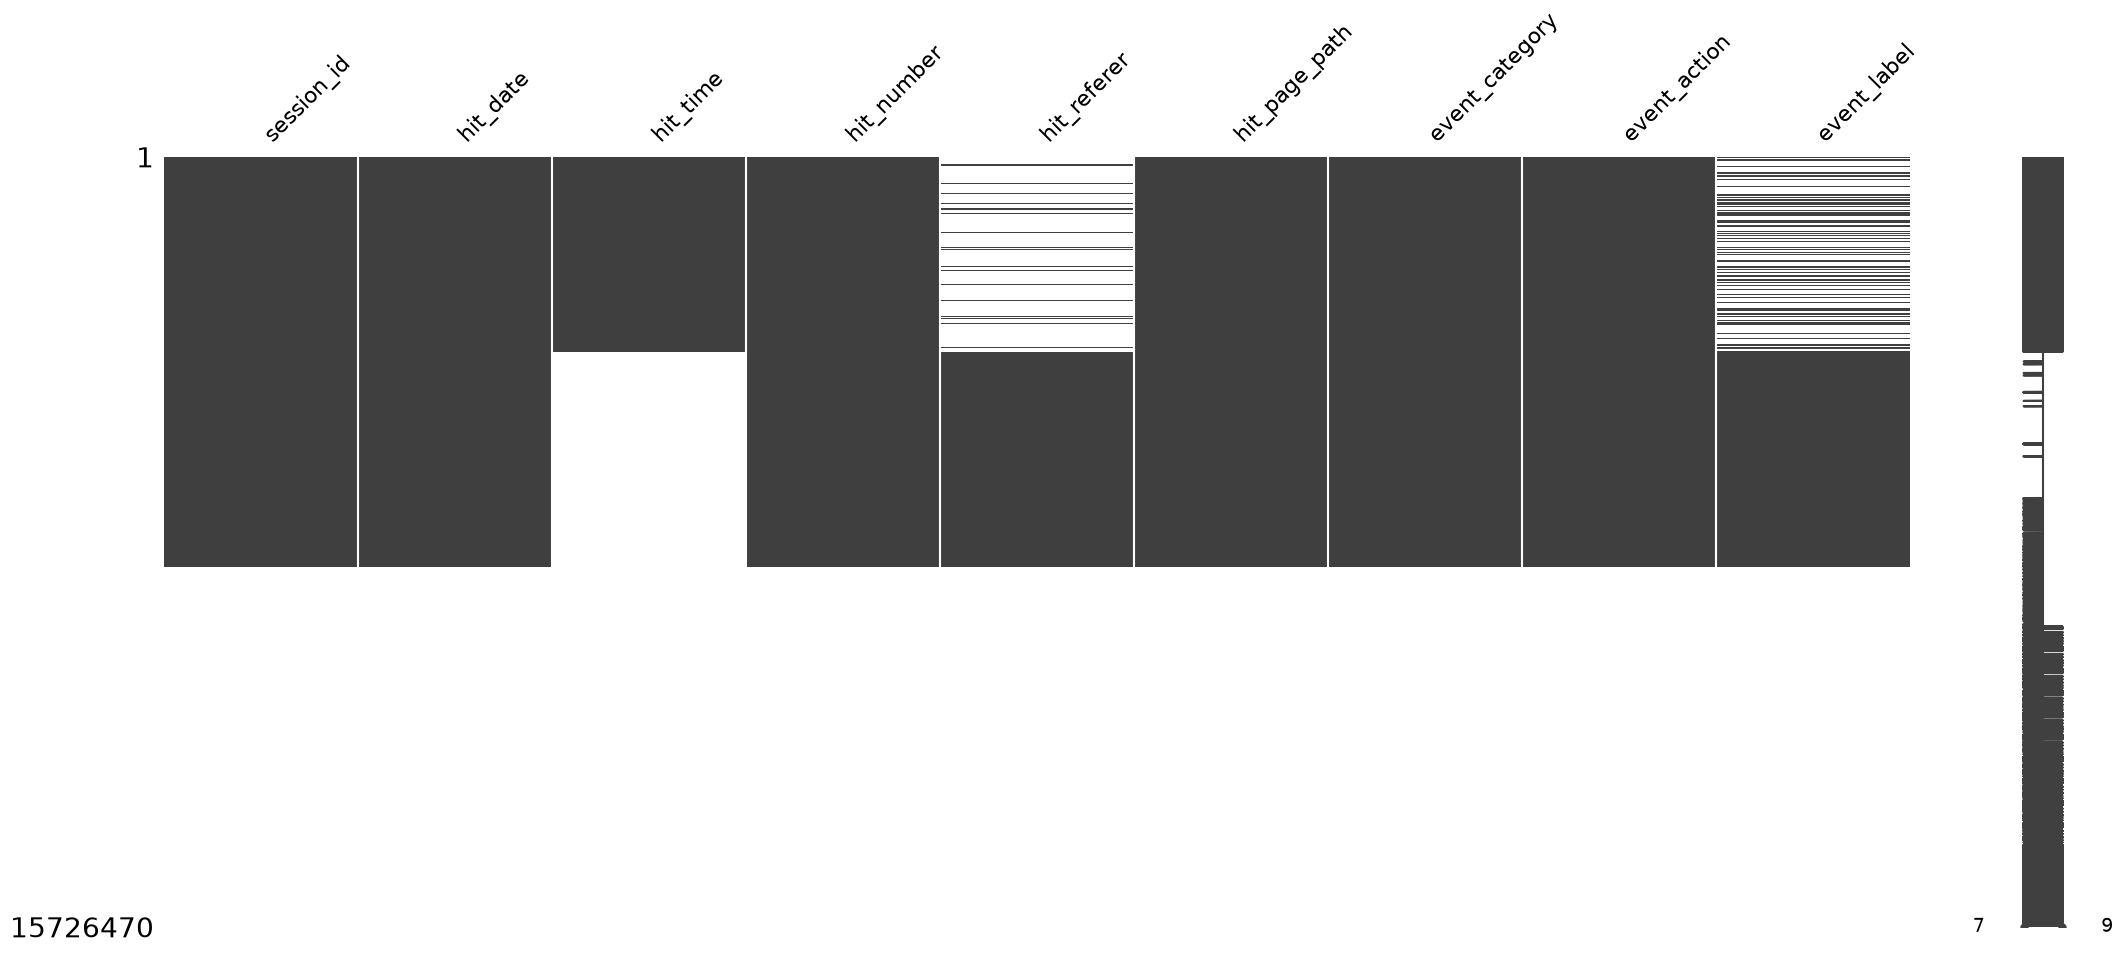

In [17]:
# Матрица пропусков hits
msno.matrix(hits_clean)

<Axes: >

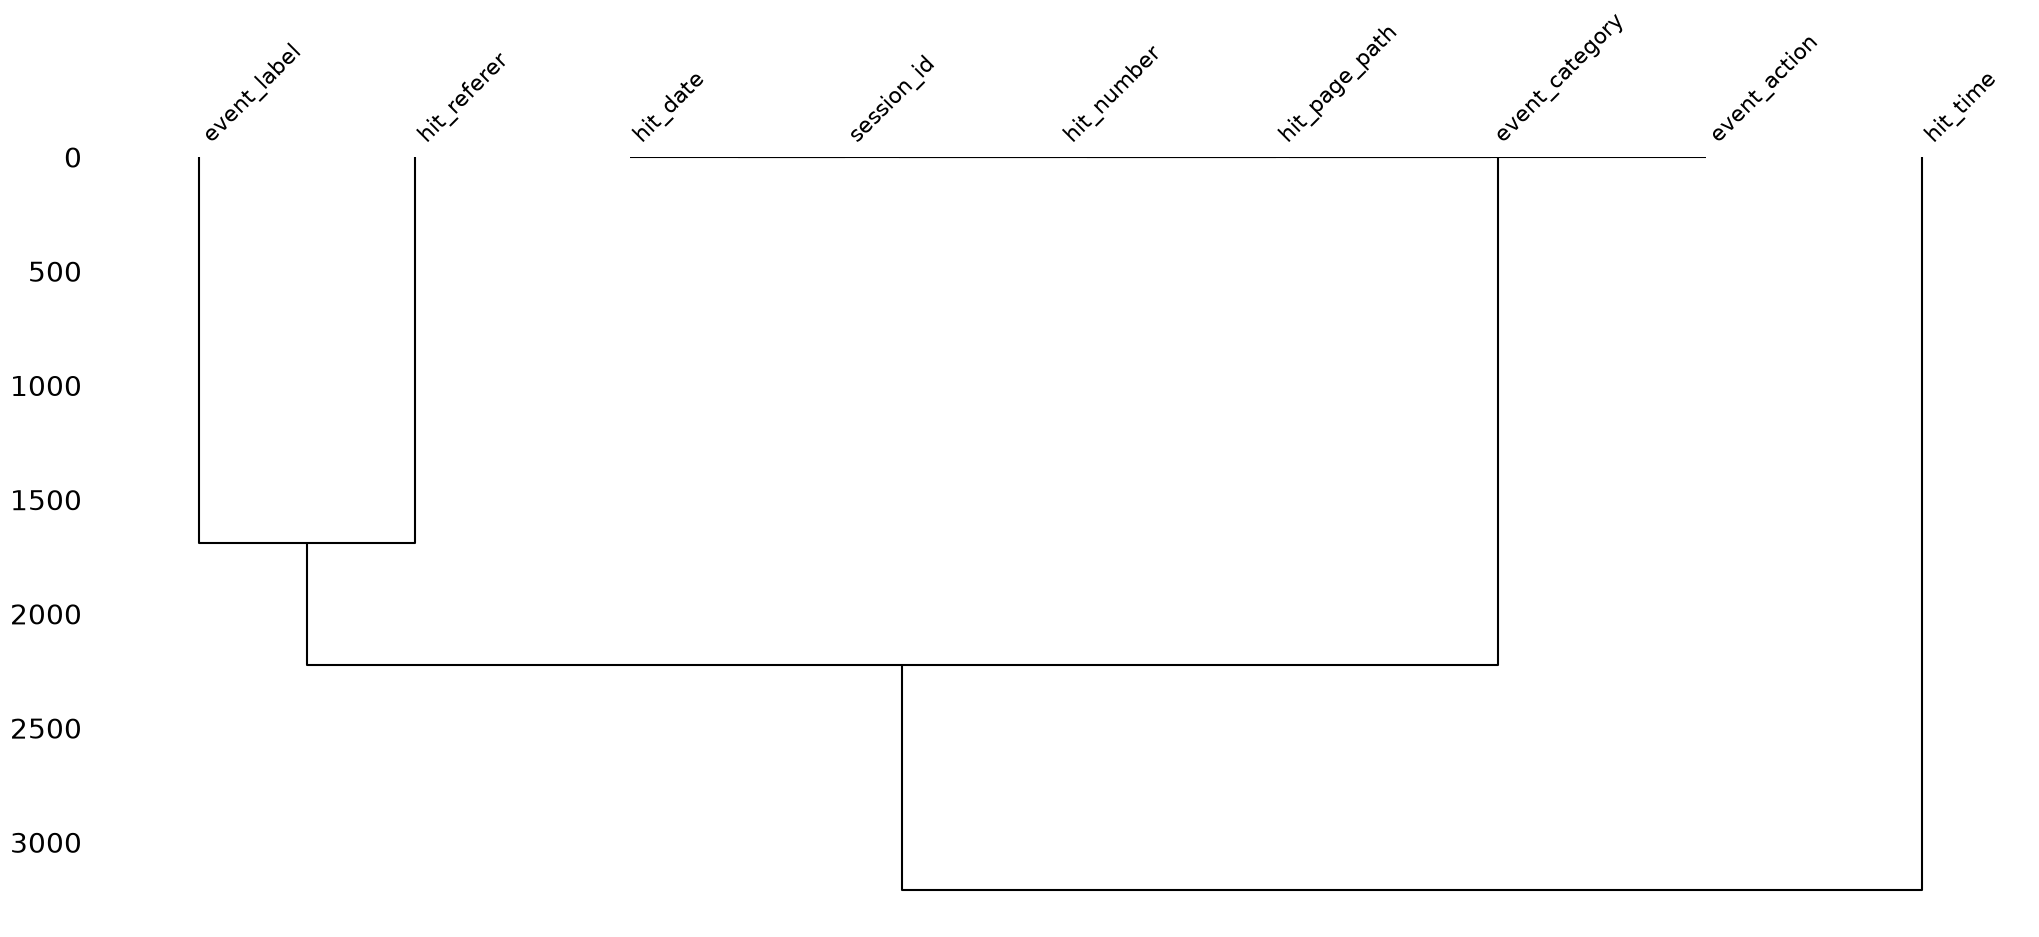

In [18]:
# Дендрограмма на основе корреляции отсутствующих значений hits
msno.dendrogram(hits_clean)

<Axes: >

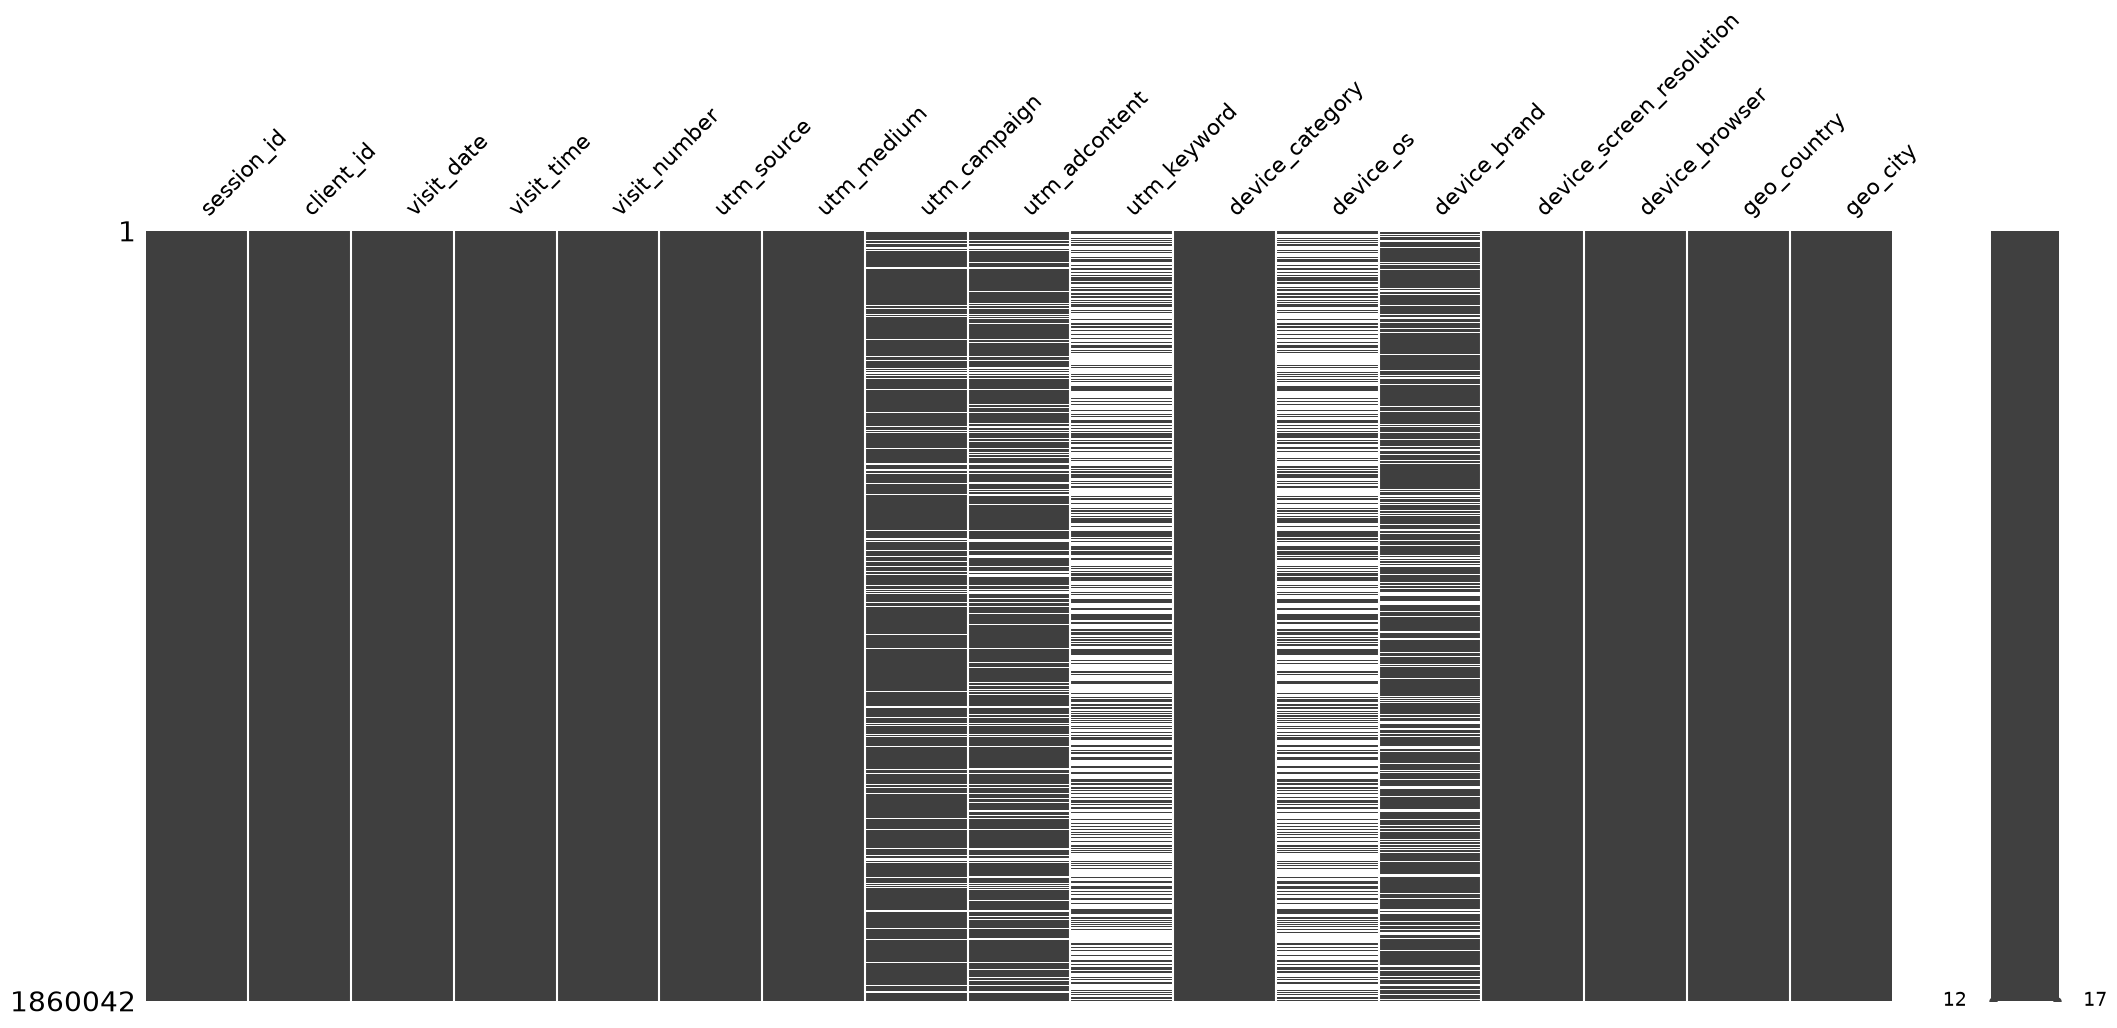

In [19]:
# Матрица пропусков sessions
msno.matrix(sessions_clean)

<Axes: >

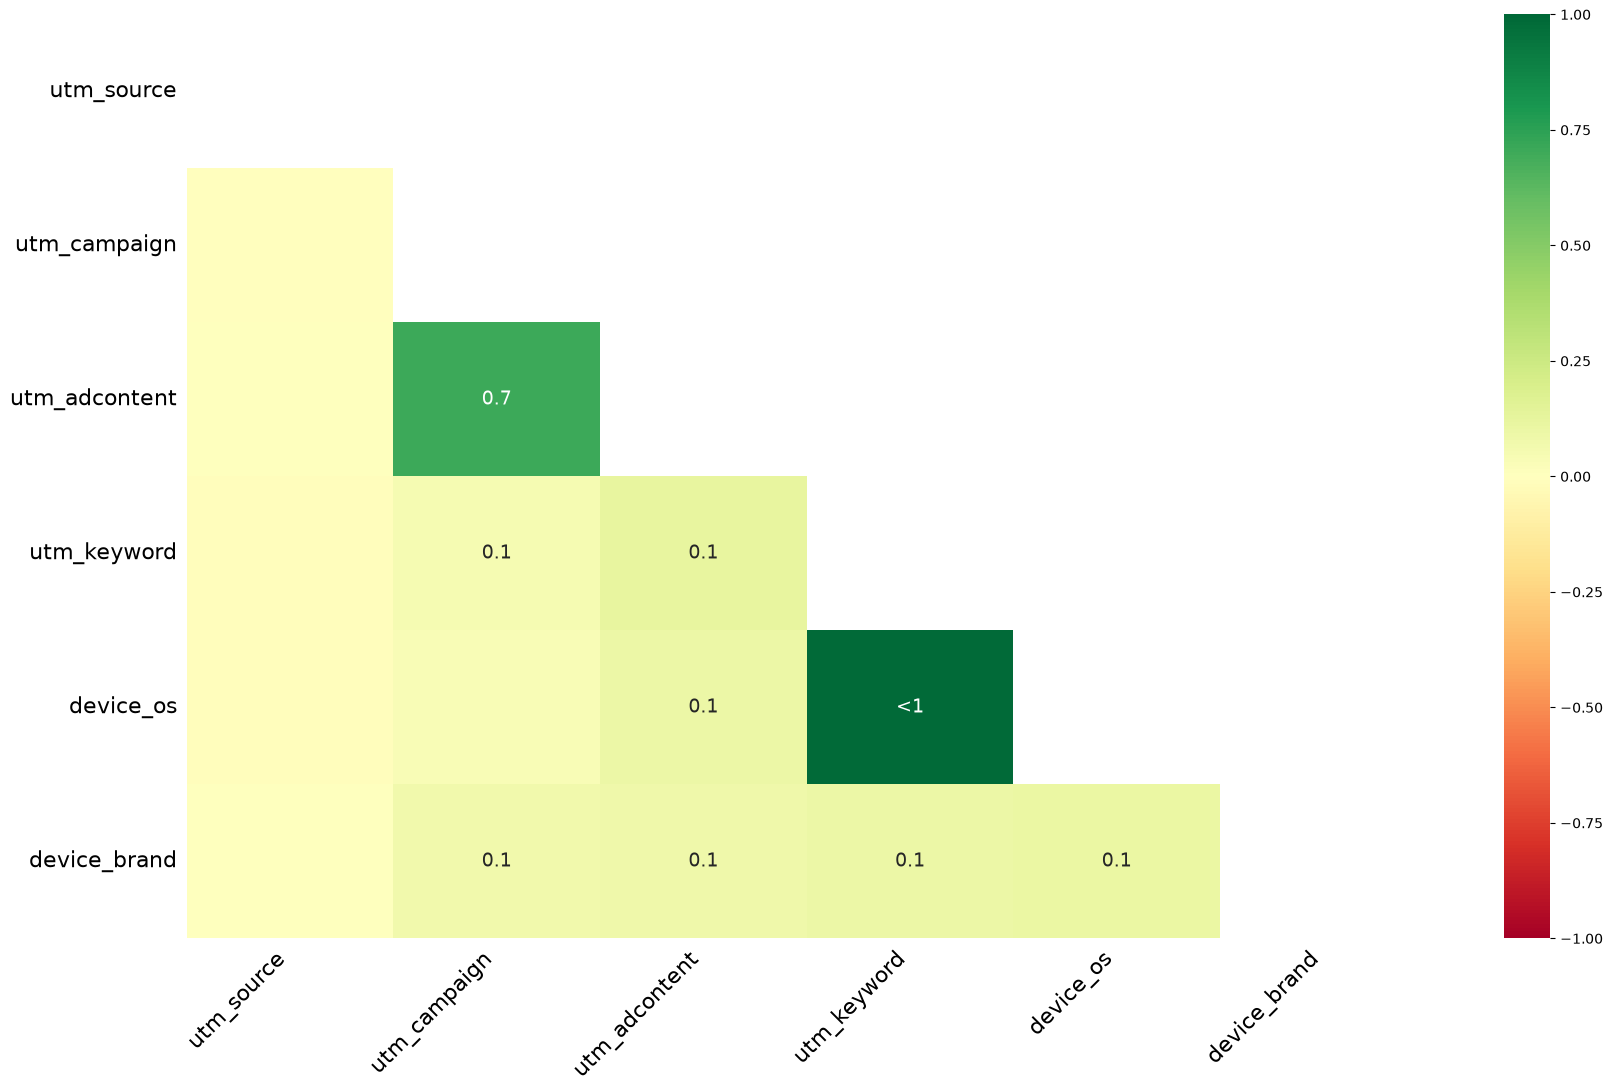

In [20]:
# Тепловая карта корреляции пропущенных значений между столбцами 
msno.heatmap(sessions_clean, cmap="RdYlGn")

Пропуски в данных зависят друг от друга, поэтому удалять или интерполировать их некорректно. 

### Проверка на дубликацию

In [21]:
# Проверка на дубликаты df_hist
dup_count_hits = handle_duplicates(hits_clean)

ОБРАБОТКА ДУБЛИКАТОВ
Дубликатов не найдено!


In [22]:
# Проверка на дубликаты df_sessions
dup_count_sessions = handle_duplicates(sessions_clean)

ОБРАБОТКА ДУБЛИКАТОВ
Дубликатов не найдено!


## Feature engineering 

### Создание таргета по целевому действию 

In [23]:
# Копируем датафреймы
hits = hits_clean.copy()
sessions = sessions_clean.copy()

In [24]:
# Создаем колонку с целевыми событиями
hits['is_target'] = hits_clean['event_action'].isin(Config.TARGET_ACTIONS)

In [25]:
# Для каждой сессии: было ли хотя бы одно целевое событие
target = hits.groupby('session_id')['is_target'].max().astype(int)

Целевая переменная была сформирована на основе наличия хотя бы одного целевого действия в рамках визита.

- 'sub_car_claim_click' - клик по оформлению заявки на авто
- 'sub_car_claim_submit_click' - отправка заявки на авто
- 'sub_open_dialog_click' - открытие диалога
- 'sub_custom_question_submit_click' - отправка вопроса
- 'sub_call_number_click' - клик по номеру телефона
- 'sub_callback_submit_click' - отправка заявки на обратный звонок
- 'sub_submit_success' - успешная отправка
- 'sub_car_request_submit_click' - отправка запроса по авто

### Объединение таргета с sessions

In [26]:
# Склеиваем таргет к сессиям 
sessions = sessions_clean.merge(
    target,
    on='session_id',
    how='left'
)

In [27]:
# Пустые значения заполняем нулем
sessions['is_target'] = (
    sessions['is_target']
    .fillna(0)
    .astype(int)
)

In [ ]:
# Смотрим рандомные 10 строк df_sessions
df_sessions.sample(n=10, random_state=42)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
27342,9175715433554881536.1629213265.1629213265,2136387730.16292,2021-08-17,18:00:00,4,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Apple,NaN,375x667,Safari,Russia,Moscow
255891,1901950595642554427.1637742649.1637742649,442832381.1637742651,2021-11-24,11:30:49,1,vFcAhRxLfOWKhvxjELkx,organic,okTXSMadDkjvntEHzIjp,LLfCasrxQzJIyuldcuWy,aXQzDWsJuGXeBXexNHjc,desktop,Windows,NaN,NaN,1600x900,Chrome,Russia,Moscow
245084,1853010306578388863.1623070595.1623070595,431437582.1623070591,2021-06-07,15:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Huawei,NaN,360x780,Chrome,Russia,Moscow
1210450,616131906550852701.1624024318.1624024318,143454388.1623157853,2021-06-18,16:00:00,7,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,desktop,NaN,NaN,NaN,1536x864,YaBrowser,Russia,Moscow
250005,1874993886247173316.1640676552.1640676552,436556033.1640676548,2021-12-28,10:29:12,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Samsung,NaN,385x854,Chrome,Russia,Kazan
787620,4276293419783414903.1636295799.1636295799,995652149.16363,2021-11-07,17:36:39,1,SzZERoLMmrEUEhDaYcyN,cpc,NaN,NaN,NaN,mobile,iOS,Apple,NaN,414x896,Safari (in-app),Russia,Moscow
94972,1177393959309943500.1633441941.1633441941,274133393.163343,2021-10-05,16:00:00,3,ZpYIoDJMcFzVoPFsHGJL,banner,gecBYcKZCPMcVYdSSzKP,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Mytishchi
181481,1566826903259187420.1632241885.1632241885,364805316.163224,2021-09-21,19:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,desktop,NaN,NaN,NaN,2560x1440,Chrome,Russia,Moscow
1062826,5501446447418276503.1630763676.1630763676,1280905317.163076,2021-09-04,16:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,tablet,NaN,Apple,NaN,768x1024,Safari,Russia,Saint Petersburg
547754,3201911108770943134.1621834640.1621834755,745503024.162184,2021-05-24,08:00:00,1,bByPQxmDaMXgpHeypKSM,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Samsung,NaN,412x732,Chrome,Russia,Novosibirsk


### Временные признаки

In [28]:
# Создаем дататайм из сессии
visit_datetime = pd.to_datetime(sessions['visit_date'] + ' ' + sessions['visit_time'])


In [29]:
# Добавляем час
sessions['hour'] = visit_datetime.dt.hour

In [30]:
# Добавляем день недели
sessions['weekday'] = visit_datetime.dt.dayofweek

### Органический трафик

In [31]:
# Создаём признак органического трафика
sessions['is_organic'] = (sessions['utm_medium'].isin(Config.ORGANIC)).astype(int)

Органический трафик — все визиты с ga_sessions.utm_medium in ('organic',
'referral', 'none')

### Реклама в соцсетях

In [32]:
sessions['is_social'] = (sessions['utm_source'].isin(Config.SOCIAL_SOURCES)).astype(int)

Реклама в социальных сетях — все визиты с ga_sessions.utm_source in
('QxAxdyPLuQMEcrdZWdWb', 'MvfHsxITijuriZxsqZqt', 'ISrKoXQCxqqYvAZICvjs',
IZEXUFLARCUMynmHNBGo', 'PlbkrSYoHuZBWfYjYnfw',
'gVRrcxiDQubJiljoTbGm').

In [33]:
sessions.head(5)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,is_target,hour,weekday,is_organic,is_social
0,9055434745589932991.1637753792.1637753792,2108382700.163776,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0,14,2,0,0
1,905544597018549464.1636867290.1636867290,210838531.163687,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0,8,6,0,1
2,9055446045651783499.1640648526.1640648526,2108385331.164065,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0,2,1,0,0
3,9055447046360770272.1622255328.1622255328,2108385564.162225,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,5,0,0
4,9055447046360770272.1622255345.1622255345,2108385564.162225,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,5,0,0


## Modeling

В качестве основной модели был выбран CatBoostClassifier, поскольку датасет содержит большое количество категориальных признаков (utm_source, utm_campaign, geo_city, device_brand и др.). CatBoost позволяет работать с категориальными признаками напрямую без One-Hot Encoding.

### Распределение классов

In [37]:
sessions.is_target.value_counts()

is_target
0    1809728
1      50314
Name: count, dtype: int64

is_target
0    97.295007
1     2.704993
Name: proportion, dtype: float64


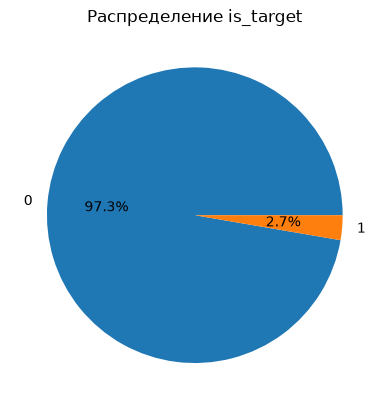

In [ ]:
# Процентное соотношение
print(sessions.is_target.value_counts(normalize=True) * 100)

# Круговой график
sessions.is_target.value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Распределение is_target')
plt.ylabel('')
plt.show()

Классы значительно дисбалансированы 

### Извлечение признаков

In [38]:
# Признаки
X = sessions.drop(columns= ['session_id', 
                            'client_id', 
                            'visit_date', 
                            'visit_time', 
                            'device_screen_resolution', 
                            'is_target'
                            ])

# Таргет
y = sessions['is_target']

In [39]:
# Категориальные признаки
cat_features = [
    'utm_source',
    'utm_medium',
    'utm_campaign',
    'utm_adcontent',
    'utm_keyword',
    'device_category',
    'device_os',
    'device_brand',
    'device_browser',
    'geo_country',
    'geo_city'
]

In [40]:
# Числовые признаки
num_features = [
    'visit_number',
    'hour',
    'weekday',          
    'is_organic',       
    'is_social'        
]

In [41]:
# Заполнение пропусков в категориальных признаках значением "unknown"
for col in cat_features:
    X[col] = X[col].fillna('unknown').astype(str)

### Разделение данных на test|train

In [42]:
# Разделение данных на test|train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=Config.RANDOM_STATE,
    stratify=y
)

train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_features
)

test_pool = Pool(
    data=X_test,
    label=y_test,
    cat_features=cat_features
)

### Настройка параметров модели 

In [43]:
# Определяем словарь параметров
param_grid = {
    'depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 5],
    'iterations': [300]
}

In [ ]:
# Инициализация модели CatBoostClassifier
model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=Config.RANDOM_STATE,
    verbose=100
)


# Поиск параметров
result = model.grid_search(
    param_grid,
    train_pool,
    cv=3,
    plot=False
)


0:	test: 0.5303711	best: 0.5303711 (0)	total: 804ms	remaining: 4m
100:	test: 0.6831917	best: 0.6831917 (100)	total: 1m 25s	remaining: 2m 48s
200:	test: 0.6925673	best: 0.6925673 (200)	total: 3m 46s	remaining: 1m 51s
299:	test: 0.6947180	best: 0.6947180 (299)	total: 6m 3s	remaining: 0us

bestTest = 0.694718018
bestIteration = 299

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.6947180	best: 0.6947180 (0)	total: 6m 4s	remaining: 42m 33s
0:	test: 0.5303711	best: 0.5303711 (0)	total: 798ms	remaining: 3m 58s
100:	test: 0.6926985	best: 0.6926985 (100)	total: 2m 1s	remaining: 3m 59s
200:	test: 0.6962687	best: 0.6962692 (199)	total: 4m 24s	remaining: 2m 10s
299:	test: 0.6978839	best: 0.6978839 (299)	total: 6m 1s	remaining: 0us

bestTest = 0.6978839142
bestIteration = 299

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric param

In [ ]:
# Оценка качества классификации
y_pred = model.predict_proba(test_pool)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred)

print(f'ROC-AUC: {roc_auc:.4f}')

ROC-AUC: 0.7034


In [ ]:
# Лучшие параметры модели
print(result['params'])

{'depth': 8, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 300}


Подбор гиперпараметров выполнялся с использованием встроенного метода grid_search CatBoost и 3-fold кросс-валидации. По результатам поиска была выбрана модель с параметрами: depth=8, learning_rate=0.1, l2_leaf_reg=3, iterations=300. Финальная модель была обучена с использованием найденных параметров.

In [44]:
# Инициализация модели по лучшим параметрам
best_model = CatBoostClassifier(
    depth=8,
    learning_rate=0.1,
    l2_leaf_reg=3,
    iterations=300,
    auto_class_weights='Balanced',
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=Config.RANDOM_STATE,
    verbose=100
)

best_model.fit(
    train_pool,
    eval_set=test_pool,
    use_best_model=True
)

0:	test: 0.6602386	best: 0.6602386 (0)	total: 2.43s	remaining: 12m 6s
100:	test: 0.7004772	best: 0.7004772 (100)	total: 2m 37s	remaining: 5m 10s
200:	test: 0.7050665	best: 0.7051114 (198)	total: 5m 29s	remaining: 2m 42s
299:	test: 0.7062447	best: 0.7062770 (298)	total: 13m 40s	remaining: 0us

bestTest = 0.7062770143
bestIteration = 298

Shrink model to first 299 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=8, eval_metric='AUC', iterations=300, l2_leaf_reg=3, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=100)

### Оценка модели

In [45]:
# Вероятности классов
y_prob = best_model.predict_proba(test_pool)[:, 1]

In [46]:
# Бинарные классы
y_pred = best_model.predict(test_pool)

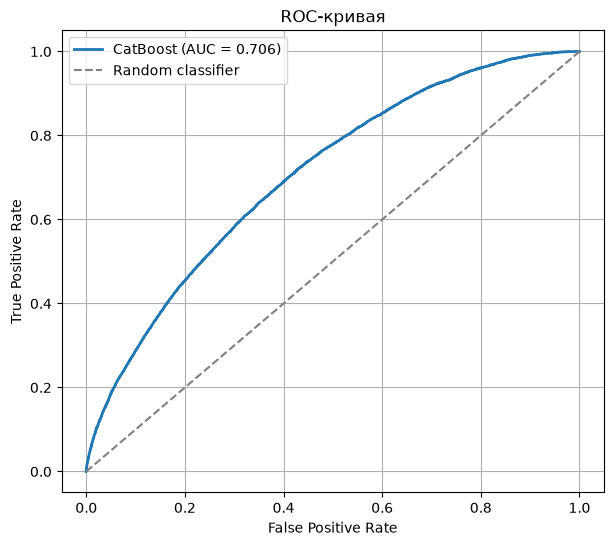

In [47]:
# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Построение
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'CatBoost (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()

plt.grid(True)

plt.show()

In [48]:
# Матрица ошибок 
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f'TN = {tn}')
print(f'FP = {fp}')
print(f'FN = {fn}')
print(f'TP = {tp}')

TN = 223897
FP = 138049
FN = 3318
TP = 6745


In [49]:
# Сводная статистика
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.62      0.76    361946
           1       0.05      0.67      0.09     10063

    accuracy                           0.62    372009
   macro avg       0.52      0.64      0.42    372009
weighted avg       0.96      0.62      0.74    372009



In [50]:
# Значимость признаков
importance = best_model.get_feature_importance(train_pool)

importance = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': importance
    })
    .sort_values('importance', ascending=False)
)

importance.head(20)

,feature,importance
3,utm_campaign,13.134469
1,utm_source,10.679299
4,utm_adcontent,9.894830
0,visit_number,9.625400
7,device_os,8.143501
12,hour,7.073938
2,utm_medium,6.448943
11,geo_city,6.397204
8,device_brand,5.877278
9,device_browser,5.020320


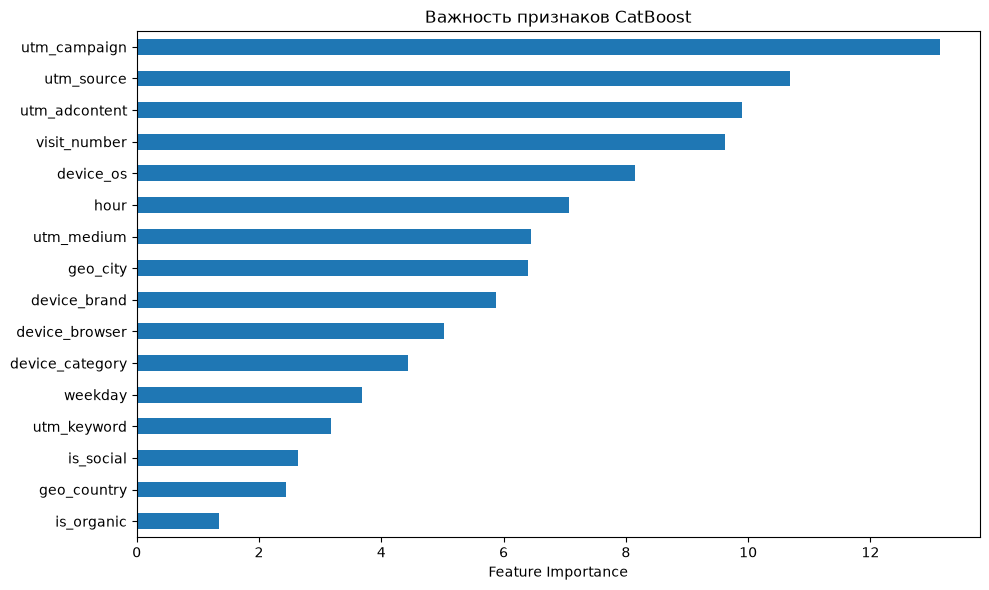

In [51]:
# Визуализация значимости признаков
importance.sort_values('importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 6),
    legend=False
)

plt.xlabel('Feature Importance')
plt.ylabel('')
plt.title('Важность признаков CatBoost')
plt.tight_layout()
plt.show()

In [52]:
# Подбор порогов вероятностей отношения к классу
thresholds = [0.9, 0.7, 0.5, 0.3, 0.1]

print("="*70)
print("РЕЗУЛЬТАТЫ ПРИ РАЗНЫХ ПОРОГАХ")
print("="*70)
print(f"{'Порог':<8} {'TP':<8} {'FP':<8} {'FN':<8} {'TN':<8} {'Recall':<10} {'Precision':<10} {'F1':<10}")
print("-"*80)

for thresh in thresholds:
    y_pred = (y_prob >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{thresh:<8.2f} {tp:<8} {fp:<8} {fn:<8} {tn:<8} {recall:<10.4f} {precision:<10.4f} {f1:<10.4f}")

РЕЗУЛЬТАТЫ ПРИ РАЗНЫХ ПОРОГАХ
Порог    TP       FP       FN       TN       Recall     Precision  F1        
--------------------------------------------------------------------------------
0.90     89       172      9974     361774   0.0088     0.3410     0.0172    
0.70     1733     16432    8330     345514   0.1722     0.0954     0.1228    
0.50     6745     138049   3318     223897   0.6703     0.0466     0.0871    
0.30     9449     270626   614      91320    0.9390     0.0337     0.0651    
0.10     10033    342611   30       19335    0.9970     0.0285     0.0553    


### Сохранение модели

In [54]:
best_model.get_best_score()

{'learn': {'Logloss': 0.5994557247331661},
 'validation': {'Logloss': 0.6194778866140572, 'AUC': 0.706277014296705}}

In [53]:
# Порог вероятности 0.7 
BEST_THRESHOLD = 0.70  # Из таблицы: лучший F1

# Сохраняем модель (в формате CatBoost)
best_model.save_model('catboost_model.cbm')

# Конфигурации
config = {
    'threshold': BEST_THRESHOLD,
    'model_version': '1.0',
    'features': X_train.columns.tolist(),
    'cat_features': cat_features
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Модель и конфигурация сохранены")

Модель и конфигурация сохранены
